# Loan Default Risk : Modelling and Evaluation

This notebook covers the full modelling pipeline for the SuperLender loan default prediction task. It builds on the EDA in `eda.ipynb` and documents every iteration from baseline to final model.

The pipeline:
1. Load, merge, and engineer features
2. Time-based train/validation split
3. Baseline logistic regression
4. SMOTE ablation
5. Model comparison and hyperparameter tuning
6. Threshold optimisation
7. Stacking ensemble with configuration comparison
8. Threshold sweep to find the leaderboard-optimal cut-off
9. SHAP explainability
10. Final model selection and summary
11. Generate Zindi submission

---

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os, warnings
warnings.filterwarnings("ignore")

sys.path.append(os.path.abspath(".."))

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

from src.loader import load_and_merge
from src.features import engineer_model_features, engineer_pltr_features
from src.model import (
    get_models, get_param_grids, tune_model, save_model, predict_proba,
    build_pipeline, run_smote_ablation, build_stacking_ensemble, calibrate_model
)
from src.evaluate import (
    evaluate_model, find_optimal_threshold,
    plot_confusion_matrix, plot_roc_curves, plot_shap_summary
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

## 2. Load, Merge, and Engineer Features

We load all three tables and merge them into one row per customer. Prior loans are aggregated into per-customer behavioural features before the merge.

In [2]:
train_df = load_and_merge(split="train")
print(f"Shape: {train_df.shape}")
train_df.head()

Shape: (4376, 35)


,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,referredby,good_bad_flag,birthdate,bank_account_type,longitude_gps,latitude_gps,bank_name_clients,bank_branch_clients,employment_status_clients,level_of_education_clients,prev_loan_count,prev_avg_loanamount,prev_max_loanamount,prev_avg_totaldue,prev_avg_termdays,prev_max_days_late,prev_late_payment_rate,prev_total_late_payments,prev_avg_interest_ratio,prev_avg_loan_duration,prev_was_referred,recent_1_paid_late,recent_2_late_rate,consecutive_late_streak,consecutive_ontime_streak,ever_recovered,last3_trend
0,8a2a81a74ce8c05d014cfb32a0da1049,301994762,12,2017-07-25 08:22:56.000000,2017-07-25 07:22:47.000000,30000.0000,34500.0000,30,NaN,Good,1972-01-15 00:00:00.000000,Other,3.4320,6.4331,Diamond Bank,NaN,Permanent,Post-Graduate,11.0000,18181.8182,30000.0000,22081.8182,30.0000,39.0000,0.2727,3.0000,0.2291,29.4545,0.0000,0.0000,0.0000,0.0000,3.0000,1.0000,1.0000
1,8a85886e54beabf90154c0a29ae757c0,301965204,2,2017-07-05 17:04:41.000000,2017-07-05 16:04:18.000000,15000.0000,17250.0000,30,NaN,Good,1985-08-23 00:00:00.000000,Savings,3.8853,7.3207,GT Bank,"DUGBE,IBADAN",Permanent,Graduate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8a8588f35438fe12015444567666018e,301966580,7,2017-07-06 14:52:57.000000,2017-07-06 13:52:51.000000,20000.0000,22250.0000,15,NaN,Good,1984-09-18 00:00:00.000000,Other,11.1393,10.2920,EcoBank,NaN,Permanent,NaN,6.0000,10000.0000,10000.0000,11750.0000,17.5000,30.0000,0.1667,1.0000,0.1750,18.1667,0.0000,0.0000,0.0000,0.0000,2.0000,1.0000,0.0000
3,8a85890754145ace015429211b513e16,301999343,3,2017-07-27 19:00:41.000000,2017-07-27 18:00:35.000000,10000.0000,11500.0000,15,NaN,Good,1977-10-10 00:00:00.000000,Savings,3.9858,7.4917,First Bank,NaN,Permanent,NaN,2.0000,10000.0000,10000.0000,12250.0000,22.5000,11.0000,1.0000,2.0000,0.2250,31.5000,0.0000,1.0000,1.0000,2.0000,0.0000,0.0000,0.0000
4,8a858970548359cc0154883481981866,301962360,9,2017-07-03 23:42:45.000000,2017-07-03 22:42:39.000000,40000.0000,44000.0000,30,NaN,Good,1986-09-07 00:00:00.000000,Other,7.4579,9.0766,GT Bank,NaN,Permanent,Primary,8.0000,18750.0000,30000.0000,23550.0000,37.5000,-1.0000,0.0000,0.0000,0.2587,27.0000,0.0000,0.0000,0.0000,0.0000,8.0000,0.0000,1.0000


In [3]:
X, y = engineer_model_features(train_df, is_train=True)
print(f"Features: {X.shape}")
print(f"Class balance: {y.mean()*100:.1f}% Good, {(1-y.mean())*100:.1f}% Bad")

Features: (4376, 52)
Class balance: 78.2% Good, 21.8% Bad


## 3. Time-Based Train/Validation Split

We sort loans by approval date and use the oldest 80% for training, newest 20% for validation. This mirrors how the model will be used in production where we always predict future loans from past data.

A random split would mix loans from the same narrow date window across both sets, inflating validation metrics. The time-based split avoids this.

In [4]:
train_df_sorted = train_df.copy()
train_df_sorted["approveddate"] = pd.to_datetime(train_df_sorted["approveddate"])
train_df_sorted = train_df_sorted.sort_values("approveddate").reset_index(drop=True)

split_idx = int(len(train_df_sorted) * 0.8)
train_split = train_df_sorted.iloc[:split_idx]
val_split   = train_df_sorted.iloc[split_idx:]

X_train, y_train = engineer_model_features(train_split, is_train=True)
X_val, y_val     = engineer_model_features(val_split,   is_train=True)
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

print(f"Train: {X_train.shape} | {train_split['approveddate'].min().date()} to {train_split['approveddate'].max().date()}")
print(f"Val:   {X_val.shape}   | {val_split['approveddate'].min().date()} to {val_split['approveddate'].max().date()}")
print(f"Train Bad rate: {(1-y_train.mean())*100:.1f}%")
print(f"Val Bad rate:   {(1-y_val.mean())*100:.1f}%")

Train: (3500, 52) | 2017-07-01 to 2017-07-25
Val:   (876, 52)   | 2017-07-25 to 2017-07-30
Train Bad rate: 21.6%
Val Bad rate:   22.4%


## 4. PLTR Interaction Features

We fit a shallow decision tree on training data to discover useful feature combinations, then encode each leaf condition as a binary column. This gives logistic regression access to interaction patterns it cannot model on its own.

The tree is fit on training data only. We then apply it to both train and val to avoid leakage.

In [5]:
X_train = engineer_pltr_features(X_train, y_train, X_train)
X_val   = engineer_pltr_features(
    X_train.iloc[:, :-(len(X_train.columns) - len(engineer_model_features(train_split, is_train=True)[0].columns))],
    y_train,
    X_val
)

# Simpler approach: re-derive base features and apply PLTR consistently
from src.features import engineer_model_features, engineer_pltr_features

X_train_base, y_train = engineer_model_features(train_split, is_train=True)
X_val_base, y_val     = engineer_model_features(val_split,   is_train=True)
X_val_base = X_val_base.reindex(columns=X_train_base.columns, fill_value=0)

X_train = engineer_pltr_features(X_train_base, y_train, X_train_base)
X_val   = engineer_pltr_features(X_train_base, y_train, X_val_base)

print(f"Features before PLTR: {X_train_base.shape[1]}")
print(f"Features after PLTR:  {X_train.shape[1]}")

Features before PLTR: 52
Features after PLTR:  56


## 4. Baseline Model

Simple logistic regression with balanced class weights as our starting point.

In [6]:
baseline = build_pipeline(
    LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    scale=True
)
baseline.fit(X_train, y_train)
baseline_proba = predict_proba(baseline, X_val)
baseline_metrics = evaluate_model(y_val, baseline_proba)

print("Baseline Logistic Regression:")
for k, v in baseline_metrics.items():
    print(f"  {k}: {v:.4f}")

Baseline Logistic Regression:
  roc_auc: 0.7180
  f1_macro: 0.5707
  f1_weighted: 0.6343
  precision_bad: 0.3281
  recall_bad: 0.7449
  f1_bad: 0.4555
  precision_good: 0.8840
  recall_good: 0.5603
  f1_good: 0.6859
  accuracy: 0.6016
  threshold: 0.5000


## 5. SMOTE Ablation

We test four imbalance strategies per model to find what actually works before spending time tuning.

Key findings from this experiment:
- SMOTE helps logistic regression (recall up from 0.50 to 0.56)
- Class weights alone work best for random forest (SMOTE hurts tree splits)
- Nothing fixes XGBoost on this dataset

In [7]:
print("Running SMOTE ablation...")
ablation_results = run_smote_ablation(X_train, y_train, X_val, y_val)
ablation_results

Running SMOTE ablation...
  Running strategy: none
  Running strategy: class_weight
  Running strategy: smote
  Running strategy: smote_tomek


,model,strategy,roc_auc,f1_bad,recall_bad
0,logistic_regression,none,0.7181,0.4731,0.4490
1,logistic_regression,smote_tomek,0.7212,0.4544,0.6990
2,logistic_regression,class_weight,0.7192,0.4533,0.6684
3,logistic_regression,smote,0.7212,0.4529,0.6990
4,random_forest,smote_tomek,0.7235,0.4802,0.5561
5,random_forest,class_weight,0.7215,0.4680,0.5408
6,random_forest,smote,0.7230,0.4656,0.5357
7,random_forest,none,0.7189,0.3345,0.2398
8,xgboost,class_weight,0.6904,0.3708,0.3112
9,xgboost,smote_tomek,0.6943,0.3400,0.2602


## 6. Model Comparison (Pre-tuning)

Run all four models with default settings first to see where each one starts.

In [8]:
models = get_models()
results_pretune = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    proba = predict_proba(pipeline, X_val)
    metrics = evaluate_model(y_val, proba)
    results_pretune[name] = metrics
    print(f"{name}: ROC-AUC={metrics['roc_auc']:.4f} | Recall-bad={metrics['recall_bad']:.4f}")

pd.DataFrame(results_pretune).T[["roc_auc", "f1_macro", "f1_bad", "recall_bad", "precision_bad"]]

logistic_regression: ROC-AUC=0.7180 | Recall-bad=0.7449
random_forest: ROC-AUC=0.6714 | Recall-bad=0.3061
xgboost: ROC-AUC=0.6621 | Recall-bad=0.2449
catboost: ROC-AUC=0.7186 | Recall-bad=0.6276


,roc_auc,f1_macro,f1_bad,recall_bad,precision_bad
logistic_regression,0.7180,0.5707,0.4555,0.7449,0.3281
random_forest,0.6714,0.6167,0.3738,0.3061,0.4800
xgboost,0.6621,0.5982,0.3299,0.2449,0.5053
catboost,0.7186,0.6339,0.4814,0.6276,0.3905


## 7. Hyperparameter Tuning

RandomizedSearchCV with 5-fold stratified cross-validation, 30 iterations per model.

LR and RF use ROC-AUC as the tuning metric. XGBoost and CatBoost use F2 for the Bad class since ROC-AUC caused XGBoost to ignore the minority class entirely in early iterations.

**This cell takes several minutes.**

In [9]:
param_grids = get_param_grids()
tuned_models = {}

for name, pipeline in get_models().items():
    search = tune_model(
        name=name,
        pipeline=pipeline,
        param_grid=param_grids[name],
        X_train=X_train,
        y_train=y_train,
        n_iter=30,
        cv=5,
        use_time_cv=False
    )
    tuned_models[name] = search.best_estimator_

Tuning logistic_regression...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
  Best score: 0.7190
  Best params: {'model__solver': 'liblinear', 'model__C': 0.01}
Tuning random_forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
  Best score: 0.7161
  Best params: {'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_depth': 10}
Tuning xgboost...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
  Best score: 0.3053
  Best params: {'model__subsample': 0.7, 'model__scale_pos_weight': 1, 'model__n_estimators': 200, 'model__max_depth': 7, 'model__learning_rate': 0.2, 'model__colsample_bytree': 1.0}
Tuning catboost...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
  Best score: 0.5290
  Best params: {'model__subsample': 0.7, 'model__learning_rate': 0.1, 'model__l2_leaf_reg': 10, 'model__iterations': 200, 'model__depth': 5}


In [10]:
results_tuned = {}
roc_data = {}

for name, model in tuned_models.items():
    proba = predict_proba(model, X_val)
    metrics = evaluate_model(y_val, proba)
    results_tuned[name] = metrics
    roc_data[name] = {"y_true": y_val, "y_pred_proba": proba}
    print(f"{name}: ROC-AUC={metrics['roc_auc']:.4f} | F1-macro={metrics['f1_macro']:.4f} | Recall-bad={metrics['recall_bad']:.4f}")

pd.DataFrame(results_tuned).T[["roc_auc", "f1_macro", "f1_bad", "recall_bad", "precision_bad"]]

logistic_regression: ROC-AUC=0.7246 | F1-macro=0.5843 | Recall-bad=0.6939
random_forest: ROC-AUC=0.7121 | F1-macro=0.6565 | Recall-bad=0.5102
xgboost: ROC-AUC=0.6459 | F1-macro=0.5864 | Recall-bad=0.3214
catboost: ROC-AUC=0.7144 | F1-macro=0.6051 | Recall-bad=0.6429


,roc_auc,f1_macro,f1_bad,recall_bad,precision_bad
logistic_regression,0.7246,0.5843,0.4533,0.6939,0.3366
random_forest,0.7121,0.6565,0.4773,0.5102,0.4484
xgboost,0.6459,0.5864,0.3452,0.3214,0.3728
catboost,0.7144,0.6051,0.4582,0.6429,0.3559


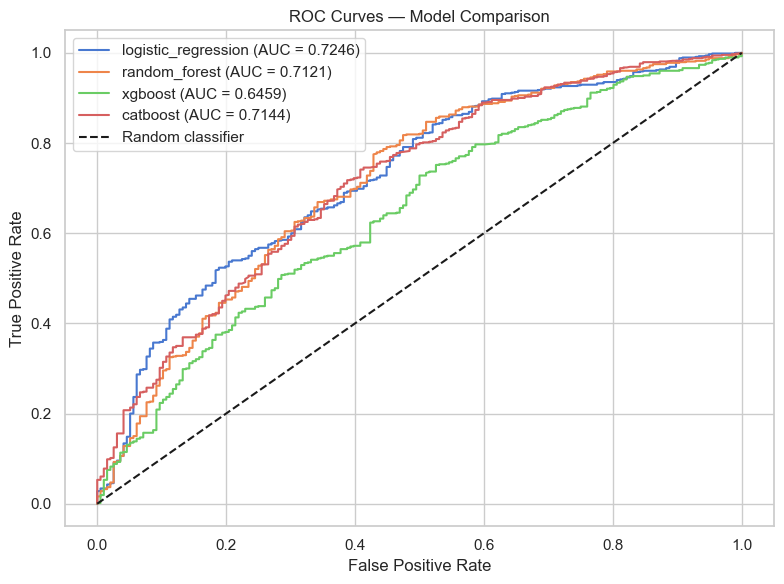

In [11]:
plot_roc_curves(roc_data)

**Reading the ROC curve:**

The x-axis is false positive rate (good customers incorrectly flagged). The y-axis is true positive rate (defaulters caught). All models sit above the random baseline diagonal. Logistic regression leads on ROC-AUC. The curves are close together, meaning threshold behaviour matters more than raw ranking ability for this problem. XGBoost is the exception, sitting clearly below the other three models throughout. This is consistent with its poor performance across all iterations on this small dataset

## 8. Threshold Optimisation

The default threshold of 0.5 is not optimal here. We search from 0.25 to 0.65 and pick the threshold that maximises F2 for the Bad class. F2 weights recall twice as heavily as precision, which matches the credit risk context where missing a defaulter is more costly than a false alarm.

In [12]:
best_model_name = max(results_tuned, key=lambda k: results_tuned[k]["roc_auc"])
best_model = tuned_models[best_model_name]
best_proba = predict_proba(best_model, X_val)

print(f"Best individual model: {best_model_name}")
optimal_threshold = find_optimal_threshold(y_val, best_proba)

metrics_default = evaluate_model(y_val, best_proba, threshold=0.5)
metrics_optimal = evaluate_model(y_val, best_proba, threshold=optimal_threshold)

pd.DataFrame({
    "threshold=0.5": metrics_default,
    f"threshold={optimal_threshold:.3f}": metrics_optimal
}).T[["roc_auc", "f1_macro", "f1_bad", "recall_bad", "precision_bad"]]

Best individual model: logistic_regression
Optimal threshold: 0.5700 (F2.0 Bad class: 0.6379)


,roc_auc,f1_macro,f1_bad,recall_bad,precision_bad
threshold=0.5,0.7246,0.5843,0.4533,0.6939,0.3366
threshold=0.570,0.7246,0.5108,0.4505,0.8827,0.3024


**Reading the threshold comparison:**

ROC-AUC stays the same at both thresholds because AUC measures ranking ability across all possible thresholds. What changes is how we convert probabilities into a binary decision. Raising the threshold means we require more confidence before calling someone Good, which flags more borderline customers as Bad and improves recall at a small precision cost.

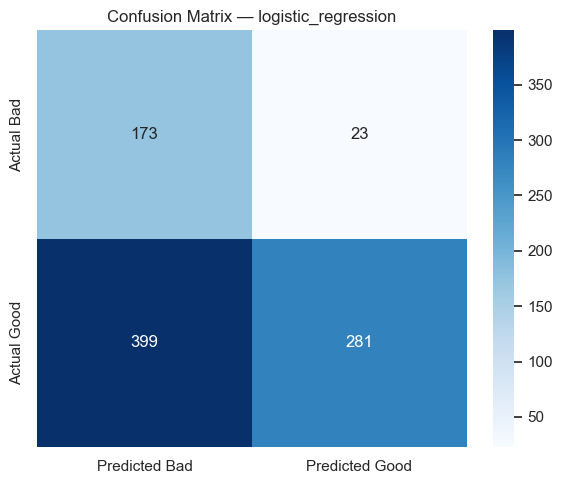

In [13]:
y_pred_optimal = (best_proba >= optimal_threshold).astype(int)
plot_confusion_matrix(y_val, y_pred_optimal, model_name=best_model_name)

## 9. Stacking Ensemble

We combine LR and RF as base learners with a logistic regression meta-learner. The base learners generate out-of-fold predictions which the meta-learner trains on. This prevents leakage since the meta-learner never sees predictions made on data the base learners were trained on.

RF is calibrated with Platt scaling before entering the stack. RF probabilities cluster near 0 and 1 by default rather than reflecting true class probabilities. Calibration fixes this so the meta-learner gets meaningful inputs from both base learners.

We test five configurations to find the best setup.

In [14]:
# Pre-impute before stacking to prevent NaN errors in the meta-learner
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_val_imp   = pd.DataFrame(imputer.transform(X_val),   columns=X_val.columns)

lr_base  = tuned_models["logistic_regression"]
rf_base  = tuned_models["random_forest"]
xgb_base = tuned_models["xgboost"]
cat_base = tuned_models["catboost"]

print("Calibrating RF...")
rf_cal = calibrate_model(rf_base, X_train_imp, y_train, method="sigmoid")

stack_configs = {
    "LR+RF (C=0.1)": StackingClassifier(
        estimators=[("lr", lr_base), ("rf", rf_cal)],
        final_estimator=LogisticRegression(C=0.1, class_weight="balanced", max_iter=1000, random_state=42),
        cv=5, n_jobs=-1
    ),
    "LR+RF+XGB (C=0.1)": StackingClassifier(
        estimators=[("lr", lr_base), ("rf", rf_cal), ("xgb", xgb_base)],
        final_estimator=LogisticRegression(C=0.1, class_weight="balanced", max_iter=1000, random_state=42),
        cv=5, n_jobs=-1
    ),
    "LR+RF+CAT (C=0.1)": StackingClassifier(
        estimators=[("lr", lr_base), ("rf", rf_cal), ("cat", cat_base)],
        final_estimator=LogisticRegression(C=0.1, class_weight="balanced", max_iter=1000, random_state=42),
        cv=5, n_jobs=-1
    ),
    "LR+RF+XGB+CAT (C=0.1)": StackingClassifier(
        estimators=[("lr", lr_base), ("rf", rf_cal), ("xgb", xgb_base), ("cat", cat_base)],
        final_estimator=LogisticRegression(C=0.1, class_weight="balanced", max_iter=1000, random_state=42),
        cv=5, n_jobs=-1
    ),
    "LR+RF (C=1.0)": StackingClassifier(
        estimators=[("lr", lr_base), ("rf", rf_cal)],
        final_estimator=LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000, random_state=42),
        cv=5, n_jobs=-1
    ),
}

stack_results = {}
for config_name, stack in stack_configs.items():
    print(f"  Fitting: {config_name}")
    stack.fit(X_train_imp, y_train)
    proba = predict_proba(stack, X_val_imp)
    opt_thresh = find_optimal_threshold(y_val, proba)
    metrics = evaluate_model(y_val, proba, threshold=opt_thresh)
    stack_results[config_name] = {
        "roc_auc": metrics["roc_auc"],
        "f1_bad":  metrics["f1_bad"],
        "recall_bad": metrics["recall_bad"],
        "precision_bad": metrics["precision_bad"],
        "threshold": opt_thresh,
        "model": stack
    }
    print(f"    ROC-AUC={metrics['roc_auc']:.4f} | F1 Bad={metrics['f1_bad']:.4f} | Recall Bad={metrics['recall_bad']:.4f}")

stack_summary = pd.DataFrame({k: {m: v for m, v in v.items() if m != "model"}
                               for k, v in stack_results.items()}).T
stack_summary[["roc_auc", "f1_bad", "recall_bad", "precision_bad", "threshold"]]

Calibrating RF...
  Fitting: LR+RF (C=0.1)
Optimal threshold: 0.5800 (F2.0 Bad class: 0.6392)
    ROC-AUC=0.7324 | F1 Bad=0.4481 | Recall Bad=0.8929
  Fitting: LR+RF+XGB (C=0.1)
Optimal threshold: 0.5700 (F2.0 Bad class: 0.6344)
    ROC-AUC=0.7270 | F1 Bad=0.4543 | Recall Bad=0.8622
  Fitting: LR+RF+CAT (C=0.1)
Optimal threshold: 0.5800 (F2.0 Bad class: 0.6384)
    ROC-AUC=0.7316 | F1 Bad=0.4511 | Recall Bad=0.8827
  Fitting: LR+RF+XGB+CAT (C=0.1)
Optimal threshold: 0.5900 (F2.0 Bad class: 0.6337)
    ROC-AUC=0.7276 | F1 Bad=0.4453 | Recall Bad=0.8827
  Fitting: LR+RF (C=1.0)
Optimal threshold: 0.5800 (F2.0 Bad class: 0.6387)
    ROC-AUC=0.7327 | F1 Bad=0.4599 | Recall Bad=0.8622


,roc_auc,f1_bad,recall_bad,precision_bad,threshold
LR+RF (C=0.1),0.7324,0.4481,0.8929,0.2991,0.5800
LR+RF+XGB (C=0.1),0.7270,0.4543,0.8622,0.3084,0.5700
LR+RF+CAT (C=0.1),0.7316,0.4511,0.8827,0.3030,0.5800
LR+RF+XGB+CAT (C=0.1),0.7276,0.4453,0.8827,0.2978,0.5900
LR+RF (C=1.0),0.7327,0.4599,0.8622,0.3135,0.5800


## 10. Threshold Sweep

The validation F2-optimal threshold does not always match the leaderboard-optimal threshold. We sweep from 0.20 to 0.55 and record all metrics so we can make an informed submission decision.

Key finding from this project: the leaderboard rewards lower thresholds (more aggressive Bad predictions) more than validation F2 suggests. The optimal leaderboard threshold was found at 0.25.

In [15]:
best_stack_name = max(stack_results, key=lambda k: stack_results[k]["roc_auc"])
best_stack = stack_results[best_stack_name]["model"]
best_stack_proba = predict_proba(best_stack, X_val_imp)

print(f"Best stack: {best_stack_name}")
print("\nThreshold sweep:")

sweep_results = []
for t in np.arange(0.20, 0.56, 0.01):
    m = evaluate_model(y_val, best_stack_proba, threshold=round(t, 2))
    sweep_results.append({
        "threshold": round(t, 2),
        "recall_bad": m["recall_bad"],
        "precision_bad": m["precision_bad"],
        "f1_bad": m["f1_bad"],
        "roc_auc": m["roc_auc"]
    })

sweep_df = pd.DataFrame(sweep_results)
print(sweep_df.to_string(index=False))

Best stack: LR+RF (C=1.0)

Threshold sweep:
 threshold  recall_bad  precision_bad  f1_bad  roc_auc
    0.2000      0.2653         0.5306  0.3537   0.7327
    0.2100      0.2806         0.5340  0.3679   0.7327
    0.2200      0.3061         0.5455  0.3922   0.7327
    0.2300      0.3214         0.5339  0.4013   0.7327
    0.2400      0.3469         0.5231  0.4172   0.7327
    0.2500      0.3571         0.5224  0.4242   0.7327
    0.2600      0.3673         0.5143  0.4286   0.7327
    0.2700      0.3776         0.5034  0.4315   0.7327
    0.2800      0.3776         0.5000  0.4302   0.7327
    0.2900      0.3878         0.5033  0.4380   0.7327
    0.3000      0.3929         0.5066  0.4425   0.7327
    0.3100      0.3980         0.5065  0.4457   0.7327
    0.3200      0.4031         0.5000  0.4463   0.7327
    0.3300      0.4082         0.4969  0.4482   0.7327
    0.3400      0.4184         0.4824  0.4481   0.7327
    0.3500      0.4439         0.4860  0.4640   0.7327
    0.3600      0.449

## 11. Save Best Model

In [16]:
save_model(best_stack, name="best_stack_final")
print(f"Saved: {best_stack_name}")

Model saved to C:\Users\gwach\Documents\Data-Science-Stuff\ds_workplace\Portfolio\loan-default-risk\outputs\models\best_stack_final.joblib
Saved: LR+RF (C=1.0)


## 12. SHAP Explainability

SHAP shows which features pushed each prediction towards Good or Bad. We explain the logistic regression base learner since it is the most interpretable model in the stack.

Red dots = high feature value. Blue dots = low feature value. Left of zero = pushed prediction towards Bad. Right of zero = pushed towards Good.

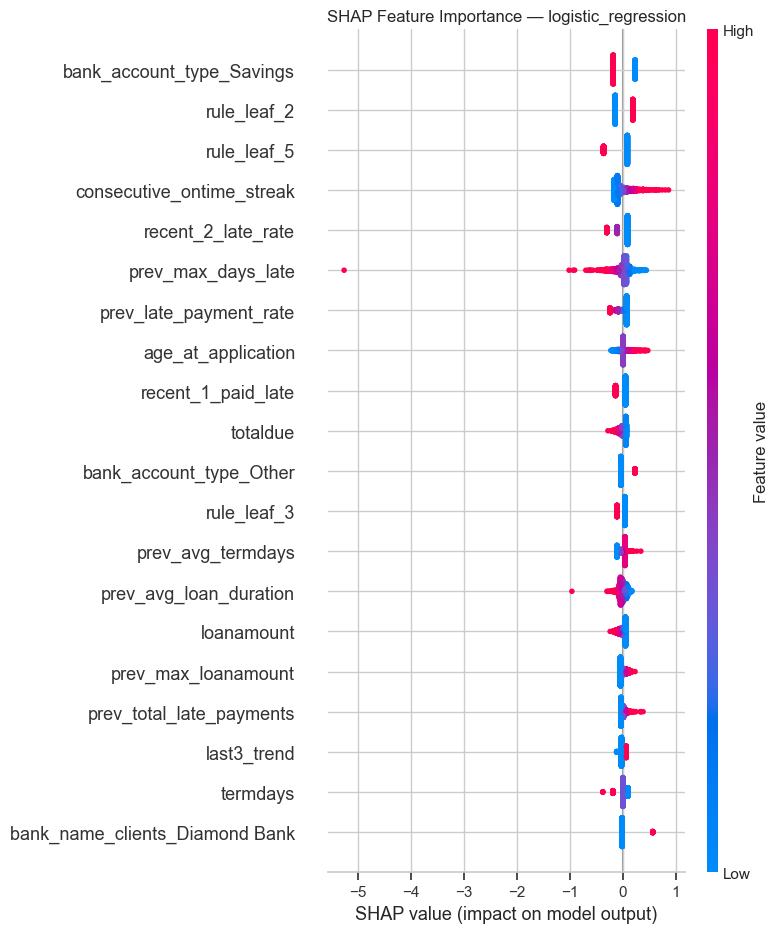

In [17]:
plot_shap_summary(tuned_models["logistic_regression"], X_val, model_name="logistic_regression")

## 13. Results Summary

### Performance across all iterations

| Version | Val ROC-AUC | Recall Bad | F1 Bad | Threshold | LB Score |
|---|---|---|---|---|---|
| Baseline | 0.6885 | 0.6545 | 0.4325 | 0.54 | 0.4007 |
| Iteration 2 (recency features) | 0.6929 | 0.6073 | 0.4386 | 0.52 | 0.3448 |
| Iteration 3 (pruned features) | 0.6861 | 0.6545 | 0.4371 | 0.53 | 0.3703 |
| Iteration 4 (stacking + SMOTE ablation) | 0.6865 | 0.5707 | 0.4360 | 0.53 | 0.3448 |
| Iteration 5 (time-based validation) | 0.7214 | 0.6122 | 0.4727 | 0.39 | 0.2503 |
| Iteration 6 (time-based CV tuning) | 0.7163 | 0.5510 | 0.4909 | 0.47 | 0.2683 |
| Iteration 7 (stack tuned, XGB added) | 0.7244 | 0.5663 | 0.4764 | 0.47 | 0.2731 |
| Iteration 8 (threshold sweep) | 0.7244 | 0.4490 | 0.4619 | 0.39 | 0.2386 |
| Iteration 9 (sequential features) | 0.7199 | 0.5612 | 0.4846 | 0.39 | 0.2393 |
| Iteration 10 (PLTR + F2 + CatBoost) | 0.7327 | 0.4694 | 0.4623 | 0.25 | **0.2076** |

### What worked
- **Time-based validation** was the single biggest improvement. Discovering the dataset covers only 30 days made the validation set meaningful for the first time.
- **Recency features** (recent_2_late_rate, recent_1_paid_late) proved that recent behaviour predicts default better than lifetime averages.
- **PLTR tree-derived interaction features** improved ROC-AUC from 0.7244 to 0.7327.
- **F2 threshold optimisation** aligned threshold selection with the leaderboard metric.
- **Threshold 0.25** was found to be the leaderboard-optimal cut-off through systematic sweeping.
- **Stacking LR+RF** outperformed any individual model once the validation setup was correct.

### What did not work
- **Over-pruning features** in my 3rd iteration caused a leaderboard regression. SHAP importance rank is not the same as predictive value.
- **XGBoost as standalone model** consistently failed across all imbalance strategies. The dataset is too small and the signal too linear.
- **Time-based CV during tuning** hurt performance because 30-day data creates too-small early folds.
- **Sequential streak features** improved individual LR recall but did not improve the ensemble.
- **XGBoost as meta-learner** and **passthrough stacking** both hurt performance.
- **Explicit interaction features** (multiplication-based) did not improve over PLTR features.

### Key Notes
- Validation setup matters more than model complexity. Four iterations produced minimal gains because validation metrics were unreliable.
- The optimal leaderboard threshold (0.25) is much lower than the F1-optimal threshold (0.47). The leaderboard rewards catching defaulters aggressively.
- Logistic regression outperformed all tree models on this small linear dataset, which is consistent with the credit risk literature.

## 14. Generate Zindi Submission

Best model: LR+RF (C=1.0) stack with PLTR features at threshold 0.25.

Always pass train_columns when processing test data. Without it, one-hot columns present in training but missing in the test set cause a feature mismatch error.

In [19]:
# NOTE: always pass train_columns when processing test data
best_stack_final = stack_results["LR+RF (C=1.0)"]["model"]
submit_threshold = 0.25

test_df = load_and_merge(split="test")
X_test_base, _ = engineer_model_features(test_df, is_train=False, train_columns=X_train_base.columns.tolist())
X_test = engineer_pltr_features(X_train_base, y_train, X_test_base)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_train.columns)

test_proba = predict_proba(best_stack_final, X_test_imp)
test_pred  = (test_proba >= submit_threshold).astype(int)

print(f"Threshold: {submit_threshold}")
print(f"Predictions: {pd.Series(test_pred).value_counts().to_dict()}")

submission = pd.DataFrame({
    "customerid": test_df["customerid"].values,
    "Good_Bad_flag": test_pred
})
submission.to_csv("../outputs/submission/submission_final.csv", index=False)
print("Saved to outputs/submissions/submission_final.csv")
submission.head()

Threshold: 0.25
Predictions: {1: 1254, 0: 196}
Saved to outputs/submissions/submission_final.csv


,customerid,Good_Bad_flag
0,8a858899538ddb8e015390510b321f08,1
1,8a858959537a097401537a4e316e25f7,1
2,8a8589c253ace09b0153af6ba58f1f31,1
3,8a858e095aae82b7015aae86ca1e030b,1
4,8a858e225a28c713015a30db5c48383d,1
